<div style="background:linear-gradient(135deg,#0d1117 0%,#161b22 100%);padding:32px;border-radius:12px;border-left:5px solid #58a6ff;">
<h1 style="color:#e6edf3;margin:0;font-size:28px;">Calidad del aire en Santiago</h1>
<p style="color:#58a6ff;margin:8px 0 0;font-size:15px;font-weight:600;">Proyecto transversal MCDI500 &mdash; Fase 1 &middot; Grupo 3</p>
<p style="color:#8b949e;margin:14px 0 0;font-size:14px;line-height:1.6;">An&aacute;lisis exploratorio de la relaci&oacute;n entre variables meteorol&oacute;gicas y los episodios cr&iacute;ticos de contaminaci&oacute;n por material particulado (MP2.5 / MP10) en la Regi&oacute;n Metropolitana.</p>
</div>

**Pregunta de investigaci&oacute;n:** &iquest;Qu&eacute; condiciones meteorol&oacute;gicas anticipan un episodio cr&iacute;tico de contaminaci&oacute;n por material particulado en Santiago?

Este notebook documenta la carga, limpieza y exploraci&oacute;n de los datos del SINCA. Cada decisi&oacute;n t&eacute;cnica queda registrada en celdas de texto (markdown) y el procesamiento en celdas de c&oacute;digo, asegurando **trazabilidad y reproducibilidad**.

---
## 1. Configuraci&oacute;n del entorno

Importamos las librer&iacute;as y definimos un estilo visual consistente para todo el notebook.

In [1]:
#Librerías para manipulación de datos
import pandas as pd
#Librerías para manipulación de datos numéricos
import numpy as np
import os
#librerías para graficar
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# Paleta y estilo premium (tema oscuro)
COL = {
    'fondo': '#0d1117', 'texto': '#e6edf3', 'sub': '#8b949e',
    'grid': '#21262d', 'acento': '#58a6ff', 'alerta': '#f85149',
    'ok': '#3fb950', 'warn': '#d29922',
}
plt.rcParams.update({
    'figure.facecolor': COL['fondo'], 'axes.facecolor': COL['fondo'],
    'savefig.facecolor': COL['fondo'], 'axes.edgecolor': COL['grid'],
    'axes.labelcolor': COL['texto'], 'text.color': COL['texto'],
    'xtick.color': COL['sub'], 'ytick.color': COL['sub'],
    'grid.color': COL['grid'], 'grid.alpha': 0.6,
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.grid': True, 'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 110,
})
print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Inspecci&oacute;n del archivo crudo

Antes de cargar, se revisan las primeras l&iacute;neas del CSV para confirmar el separador y la codificaci&oacute;n. Los archivos del SINCA usan punto y coma (`;`) como separador y coma decimal.

In [2]:
#Se carga el dataset para revisar su estructura
ruta = '../data/raw/sinca_santiago.csv'
with open(ruta, encoding='latin-1') as f:
    for i in range(4):
        print(i, repr(f.readline()))


0 'fecha;estacion;comuna;MP2.5;MP10;temperatura;humedad;presion;viento;radiacion;inversion_termica;dia_semana;es_finde;es_festivo\n'
1 '01-01-2022 00:00;Pudahuel;Pudahuel;20,9;47,3;20,2;51,9;1016,9;1,9;35,0;1;5;1;1\n'
2 '01-01-2022 01:00;Pudahuel;Pudahuel;5,1;19,1;17,2;57,3;1019,4;2,9;28,0;0;5;1;1\n'
3 '01-01-2022 02:00;Pudahuel;Pudahuel;5,0;18,8;14,6;56,1;1016,3;2,7;52,0;0;5;1;1\n'


---
## 3. Carga de los datos
Se especifica `sep=';'`, `decimal=','` y `encoding='latin-1'` (formato SINCA). Se convierte la columna `fecha` a tipo datetime y se deriva las variables temporales para el an&aacute;lisis. Se está trabajando con magnitudes físicas, por lo tanto se es necesario analizarlas con sus respectivas unidades de medidas

In [3]:

# Carga optimizada del CSV con pandas, especificando separador, decimal y encoding
df = pd.read_csv(ruta, sep=';', decimal=',', encoding='latin-1')

# Limpieza de filas fantasmas/vacías por si acaso
df = df.dropna(how='all')

#configuración de la fecha, con manejo de errores para formatos mixtos
try:
    df['fecha'] = pd.to_datetime(df['fecha'], format='mixed', cache=True)
    df['fecha'] = df['fecha'].dt.floor('h')
except Exception as e:
    print(f"Aviso con datetime automático: {e}. Aplicando plan B...")
    df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
    df['fecha'] = df['fecha'].dt.floor('h')

#diccionarios para mapear las variables cualitativas y cuantitativas, con sus unidades
dicc_columnas = {
    'MP2.5': ['µg/m³', 'cuantitativo'],
    'MP10': ['µg/m³', 'cuantitativo'],
    'temperatura': ['°C', 'cuantitativo'],
    'humedad': ['%', 'cuantitativo'],
    'presion': ['hPa', 'cuantitativo'],
    'viento': ['m/s', 'cuantitativo'],
    'radiacion': ['W/m²', 'cuantitativo'],
    'inversion_termica': ['','cualitativo'],
    'dia_semana': ['','cualitativo'],
    'es_finde': ['', 'cualitativo'],
    'es_festivo': ['', 'cualitativo'],
    'fecha': [' ', 'temporal'],
    'estacion': ['', 'cualitativo'],
    'comuna': ['', 'cualitativo']
}

dicc_dias_semana = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}
dicc_booleano = {0: 'No', 1: 'Sí'}   

# mapeo en el ddcionario para las variables cualitativas, aplicando .map() que es más eficiente que .apply()
mapeos = {
    'dia_semana': dicc_dias_semana,
    'es_finde': dicc_booleano,
    'es_festivo': dicc_booleano,
    'inversion_termica': dicc_booleano
}
# reemplazo de valores según diccionario
for col, dicc in mapeos.items():
    if col in df.columns:
        # Usamos .map() que trabaja a nivel de memoria C
        df[col] = df[col].map(dicc)
        
# nuevos encabezados con unidades para las variables cuantitativas, aplicando comprensión de diccionario
nuevos_encabezados = {
    col: f"{col} ({valores[0]})" if valores[0].strip() else col
    for col, valores in dicc_columnas.items()
    if col in df.columns
}
df.rename(columns=nuevos_encabezados, inplace=True)


#convertir la fecha a formato de texto con AM/PM
df['fecha'] = pd.to_datetime(df['fecha']).dt.strftime('%Y-%m-%d %I:%M %p')
df.head()

,fecha,estacion,comuna,MP2.5 (µg/m³),MP10 (µg/m³),temperatura (°C),humedad (%),presion (hPa),viento (m/s),radiacion (W/m²),inversion_termica,dia_semana,es_finde,es_festivo
0,2022-01-01 12:00 AM,Pudahuel,Pudahuel,20.9,47.3,20.2,51.9,1016.9,1.9,35.0,Sí,Sábado,Sí,Sí
1,2022-01-01 01:00 AM,Pudahuel,Pudahuel,5.1,19.1,17.2,57.3,1019.4,2.9,28.0,No,Sábado,Sí,Sí
2,2022-01-01 02:00 AM,Pudahuel,Pudahuel,5.0,18.8,14.6,56.1,1016.3,2.7,52.0,No,Sábado,Sí,Sí
3,2022-01-01 03:00 AM,Pudahuel,Pudahuel,2.0,14.1,14.5,59.7,1014.5,3.4,0.0,No,Sábado,Sí,Sí
4,2022-01-01 04:00 AM,Pudahuel,Pudahuel,11.9,27.7,16.8,54.9,1020.6,0.9,2.0,No,Sábado,Sí,Sí


---
## 4. Inspecci&oacute;n general y calidad de los datos

Se revisan los tipos de datos, estad&iacute;sticas descriptivas y valores faltantes antes de limpiar.

In [4]:
df.info()
df.describe().round(1)

<class 'pandas.DataFrame'>
RangeIndex: 192720 entries, 0 to 192719
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   fecha              192720 non-null  str    
 1   estacion           192720 non-null  str    
 2   comuna             192720 non-null  str    
 3   MP2.5 (µg/m³)      189830 non-null  float64
 4   MP10 (µg/m³)       189830 non-null  float64
 5   temperatura (°C)   192720 non-null  float64
 6   humedad (%)        189830 non-null  float64
 7   presion (hPa)      189830 non-null  float64
 8   viento (m/s)       192720 non-null  float64
 9   radiacion (W/m²)   189830 non-null  float64
 10  inversion_termica  192720 non-null  str    
 11  dia_semana         192720 non-null  str    
 12  es_finde           192720 non-null  str    
 13  es_festivo         192720 non-null  str    
dtypes: float64(7), str(7)
memory usage: 20.6 MB


,MP2.5 (µg/m³),MP10 (µg/m³),temperatura (°C),humedad (%),presion (hPa),viento (m/s),radiacion (W/m²)
count,189830.0,189830.0,192720.0,189830.0,189830.0,192720.0,189830.0
mean,26.2,54.5,14.0,62.2,1013.0,3.1,307.0
std,18.6,30.5,7.8,9.7,4.1,1.6,387.2
min,2.0,5.4,-4.0,21.4,996.6,0.2,0.0
25%,10.5,28.4,8.4,55.6,1010.1,2.0,0.0
50%,24.4,50.8,14.0,62.2,1013.0,2.9,43.0
75%,39.0,75.0,19.6,68.7,1015.9,4.0,584.0
max,97.4,184.0,35.0,100.0,1028.9,15.8,1417.0


---
## 5. Limpieza de datos

La cantidad de datos por magnitudes son distintas. Cocnsiderando los factores estadísticos se concluye que todas las magnitudes físicas tienen un comportamiento simetrico porque sus medianas son similares a sus medias, a excepción de la radiación. Por lo tanto en vez de agregar medias a las celdas faltantes, se realiza una limpieza del dataset.

In [5]:
# ============================================================
# Limpieza, validación y trazabilidad del dataset
# Proyecto F3 - Calidad del Aire Santiago
# ============================================================

import pandas as pd
from IPython.display import display

# ------------------------------------------------------------
# 1. Validar que el DataFrame principal exista
# ------------------------------------------------------------

if "df" not in globals():
    raise NameError(
        "El DataFrame 'df' no existe. "
        "Ejecuta primero la celda de carga del dataset antes de esta sección."
    )

# ------------------------------------------------------------
# 2. Copia segura para evitar alterar accidentalmente datos base
# ------------------------------------------------------------

df_limpio = df.copy()

# ------------------------------------------------------------
# 3. Diagnóstico inicial
# ------------------------------------------------------------

filas_iniciales = len(df_limpio)
columnas_iniciales = df_limpio.shape[1]

nulos_por_columna = (
    df_limpio
    .isna()
    .sum()
    .sort_values(ascending=False)
)

total_nulos = int(nulos_por_columna.sum())

print("=" * 70)
print("DIAGNÓSTICO INICIAL DEL DATASET")
print("=" * 70)
print(f"Filas iniciales      : {filas_iniciales:,}")
print(f"Columnas iniciales   : {columnas_iniciales:,}")
print(f"Valores nulos totales: {total_nulos:,}")
print("=" * 70)

print("\nValores nulos por columna:")
display(nulos_por_columna.to_frame("nulos"))

# ------------------------------------------------------------
# 4. Limpieza controlada
# ------------------------------------------------------------

df_limpio = (
    df_limpio
    .dropna()
    .reset_index(drop=True)
)

filas_finales = len(df_limpio)
filas_eliminadas = filas_iniciales - filas_finales

porcentaje_eliminado = (
    filas_eliminadas / filas_iniciales * 100
    if filas_iniciales > 0
    else 0
)

# ------------------------------------------------------------
# 5. Resumen de limpieza
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RESUMEN DE LIMPIEZA DEL DATASET")
print("=" * 70)
print(f"Registros iniciales : {filas_iniciales:,}")
print(f"Registros finales   : {filas_finales:,}")
print(f"Registros eliminados: {filas_eliminadas:,}")
print(f"% eliminado         : {porcentaje_eliminado:.2f}%")
print("=" * 70)

# ------------------------------------------------------------
# 6. Reemplazar df por versión limpia
# ------------------------------------------------------------

df = df_limpio.copy()

# ------------------------------------------------------------
# 7. Validación final
# ------------------------------------------------------------

print("\nEstructura final del dataset limpio:")
df.info()

print("\nResumen estadístico del dataset limpio:")
display(df.describe(include="all").round(2))

DIAGNÓSTICO INICIAL DEL DATASET
Filas iniciales      : 192,720
Columnas iniciales   : 14
Valores nulos totales: 14,450

Valores nulos por columna:


,nulos
MP10 (µg/m³),2890
MP2.5 (µg/m³),2890
presion (hPa),2890
radiacion (W/m²),2890
humedad (%),2890
estacion,0
temperatura (°C),0
comuna,0
fecha,0
viento (m/s),0



RESUMEN DE LIMPIEZA DEL DATASET
Registros iniciales : 192,720
Registros finales   : 178,709
Registros eliminados: 14,011
% eliminado         : 7.27%

Estructura final del dataset limpio:
<class 'pandas.DataFrame'>
RangeIndex: 178709 entries, 0 to 178708
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   fecha              178709 non-null  str    
 1   estacion           178709 non-null  str    
 2   comuna             178709 non-null  str    
 3   MP2.5 (µg/m³)      178709 non-null  float64
 4   MP10 (µg/m³)       178709 non-null  float64
 5   temperatura (°C)   178709 non-null  float64
 6   humedad (%)        178709 non-null  float64
 7   presion (hPa)      178709 non-null  float64
 8   viento (m/s)       178709 non-null  float64
 9   radiacion (W/m²)   178709 non-null  float64
 10  inversion_termica  178709 non-null  str    
 11  dia_semana         178709 non-null  str    
 12  es_finde           17

,fecha,estacion,comuna,MP2.5 (µg/m³),MP10 (µg/m³),temperatura (°C),humedad (%),presion (hPa),viento (m/s),radiacion (W/m²),inversion_termica,dia_semana,es_finde,es_festivo
count,178709,178709,178709,178709.00,178709.00,178709.00,178709.00,178709.00,178709.00,178709.00,178709,178709,178709,178709
unique,17520,11,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,7,2,2
top,2022-01-01 09:00 AM,Cerro Navia,Cerro Navia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,Domingo,No,No
freq,11,16291,16291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,108335,25679,127402,170407
mean,NaN,NaN,NaN,26.19,54.50,14.01,62.17,1013.00,3.10,307.35,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,18.57,30.46,7.77,9.68,4.12,1.57,387.33,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,2.00,5.40,-4.00,21.40,996.60,0.20,0.00,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,10.40,28.30,8.40,55.60,1010.10,2.00,0.00,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,24.40,50.80,14.00,62.20,1013.00,2.90,43.00,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,38.90,75.00,19.60,68.70,1015.90,4.00,584.00,NaN,NaN,NaN,NaN


Se logra observar en la descripción que con la limpieza se tiene un dataset limpio.

In [6]:
# ============================================================
# Limpieza robusta y exportación del dataset procesado
# Proyecto F3 - Calidad del Aire Santiago
# ============================================================

import os
import re
import unicodedata

# 1. Normalizar nombres de columnas
def normalizar_columna(col):
    col = str(col).strip()
    col = col.replace("µ", "u")
    col = unicodedata.normalize("NFKD", col)
    col = "".join(c for c in col if not unicodedata.combining(c))
    col = col.lower()
    col = re.sub(r"\s*\(.*?\)", "", col)
    col = col.replace(" ", "_")
    col = col.replace(".", "_")
    col = re.sub(r"_+", "_", col)
    return col.strip("_")

df.columns = [normalizar_columna(c) for c in df.columns]

print("Columnas normalizadas:")
print(df.columns.tolist())

# 2. Definir columnas clave existentes
columnas_clave = [
    "mp2_5",
    "mp10",
    "temperatura",
    "humedad",
    "presion",
    "viento",
    "radiacion"
]

columnas_existentes = [c for c in columnas_clave if c in df.columns]

if not columnas_existentes:
    raise ValueError(
        "No se encontraron columnas clave para limpieza. "
        f"Columnas disponibles: {df.columns.tolist()}"
    )

print(f"Columnas usadas para limpieza: {columnas_existentes}")

# 3. Eliminar registros incompletos solo en columnas relevantes
filas_antes = len(df)

df = (
    df
    .dropna(subset=columnas_existentes)
    .reset_index(drop=True)
)

filas_eliminadas = filas_antes - len(df)

print(f"Registros iniciales: {filas_antes:,}")
print(f"Registros eliminados: {filas_eliminadas:,}")
print(f"Registros finales: {len(df):,}")

# 4. Guardar dataset procesado
ruta_salida = "../data/processed/sinca_limpio.csv"

os.makedirs(os.path.dirname(ruta_salida), exist_ok=True)

df.to_csv(
    ruta_salida,
    index=False,
    encoding="utf-8"
)

print(f"Dataset limpio guardado correctamente en: {ruta_salida}")

Columnas normalizadas:
['fecha', 'estacion', 'comuna', 'mp2_5', 'mp10', 'temperatura', 'humedad', 'presion', 'viento', 'radiacion', 'inversion_termica', 'dia_semana', 'es_finde', 'es_festivo']
Columnas usadas para limpieza: ['mp2_5', 'mp10', 'temperatura', 'humedad', 'presion', 'viento', 'radiacion']
Registros iniciales: 178,709
Registros eliminados: 0
Registros finales: 178,709


Dataset limpio guardado correctamente en: ../data/processed/sinca_limpio.csv


---
## 6. Definici&oacute;n de episodio cr&iacute;tico

Existen 2 posibles episodios críticos: El primero es un MP2.5 promedio diario superior a 49 (µg/m³) y el segundo es un MP10 promedio diario superior a 179(µg/m³). Ambos umbrales son concentraciones necesarias para un aire regular. Con estos 2 episodios críticos se podrá definir condiciones meteorológicas y anticipar una alerta. La Normativa ambiental chilena exige que un promedio diario mínimo se calcule con 18Hr. Por lo tanto hay que eliminar filas asociadas a días con menos de 18 hrs muestreados

In [7]:
# Convertir 'fecha' a datetime de forma robusta.
# Se intenta primero el formato explícito definido en la carga ('%Y-%m-%d %I:%M %p');
# si la columna ya viniera en otro tipo/formato, se hace un fallback silencioso.
# Esto evita el UserWarning de inferencia de formato de pandas.
if not pd.api.types.is_datetime64_any_dtype(df['fecha']):
    try:
        df['fecha'] = pd.to_datetime(df['fecha'], format='%Y-%m-%d %I:%M %p')
    except (ValueError, TypeError):
        df['fecha'] = pd.to_datetime(df['fecha'], format='mixed')

# Crear una columna temporal solo con la fecha (AAAA-MM-DD) para agrupar por día
df['solo_fecha'] = df['fecha'].dt.date

# Filtrar el DataFrame manteniendo solo los grupos que tienen 18 o más registros
df_filtrado = df.groupby(['solo_fecha', 'comuna']).filter(lambda x: len(x) >= 18)

# Eliminar la columna temporal si ya no la necesitas
df_filtrado = df_filtrado.drop(columns=['solo_fecha'])

# Verificar cuántos datos quedaron
print(f"Registros originales: {len(df)}")
print(f"Registros después del filtro: {len(df_filtrado)}")
df_filtrado.head()

Registros originales: 178709
Registros después del filtro: 178558


,fecha,estacion,comuna,mp2_5,mp10,temperatura,humedad,presion,viento,radiacion,inversion_termica,dia_semana,es_finde,es_festivo
0,2022-01-01 00:00:00,Pudahuel,Pudahuel,20.9,47.3,20.2,51.9,1016.9,1.9,35.0,Sí,Sábado,Sí,Sí
1,2022-01-01 01:00:00,Pudahuel,Pudahuel,5.1,19.1,17.2,57.3,1019.4,2.9,28.0,No,Sábado,Sí,Sí
2,2022-01-01 02:00:00,Pudahuel,Pudahuel,5.0,18.8,14.6,56.1,1016.3,2.7,52.0,No,Sábado,Sí,Sí
3,2022-01-01 03:00:00,Pudahuel,Pudahuel,2.0,14.1,14.5,59.7,1014.5,3.4,0.0,No,Sábado,Sí,Sí
4,2022-01-01 04:00:00,Pudahuel,Pudahuel,11.9,27.7,16.8,54.9,1020.6,0.9,2.0,No,Sábado,Sí,Sí


In [8]:
# ============================================================
# Cálculo de promedios diarios y detección de días críticos
# Proyecto F3 - Calidad del Aire Santiago
# ============================================================

import pandas as pd
import unicodedata
import re

# 1. Función para normalizar nombres de columnas
def normalizar_columna(col):
    col = str(col).strip()
    col = col.replace("µ", "u")
    col = unicodedata.normalize("NFKD", col)
    col = "".join(c for c in col if not unicodedata.combining(c))
    col = col.lower()
    col = re.sub(r"\s*\(.*?\)", "", col)
    col = col.replace(" ", "_")
    col = col.replace(".", "_")
    col = re.sub(r"_+", "_", col)
    return col.strip("_")

# 2. Trabajar sobre una copia segura
df_work = df_filtrado.copy()
df_work.columns = [normalizar_columna(c) for c in df_work.columns]

print("Columnas disponibles:")
print(df_work.columns.tolist())

# 3. Validar columnas obligatorias
columnas_requeridas = ["fecha", "comuna", "estacion", "mp2_5", "mp10"]

faltantes = [c for c in columnas_requeridas if c not in df_work.columns]

if faltantes:
    raise KeyError(
        f"Faltan columnas requeridas: {faltantes}. "
        f"Columnas disponibles: {df_work.columns.tolist()}"
    )

# 4. Asegurar formato de fecha
df_work["fecha"] = pd.to_datetime(
    df_work["fecha"],
    errors="coerce"
)

df_work = df_work.dropna(subset=["fecha"]).copy()
df_work["solo_fecha"] = df_work["fecha"].dt.date

# 5. Asegurar formato numérico en contaminantes
for col in ["mp2_5", "mp10"]:
    df_work[col] = pd.to_numeric(
        df_work[col],
        errors="coerce"
    )

# 6. Eliminar registros sin contaminantes principales
df_work = df_work.dropna(
    subset=["mp2_5", "mp10"]
).reset_index(drop=True)

# 7. Umbrales de referencia
UMBRAL25 = 49
UMBRAL10 = 179

# 8. Promedios diarios por fecha, comuna y estación
mp25_diario = (
    df_work
    .groupby(["solo_fecha", "comuna", "estacion"], as_index=False)
    .agg(mp2_5_promedio_diario=("mp2_5", "mean"))
)

mp10_diario = (
    df_work
    .groupby(["solo_fecha", "comuna", "estacion"], as_index=False)
    .agg(mp10_promedio_diario=("mp10", "mean"))
)

# 9. Identificación de días críticos
mp25_critico = (
    mp25_diario[mp25_diario["mp2_5_promedio_diario"] > UMBRAL25]
    .sort_values(by=["solo_fecha", "comuna", "estacion"])
    .reset_index(drop=True)
)

mp10_critico = (
    mp10_diario[mp10_diario["mp10_promedio_diario"] > UMBRAL10]
    .sort_values(by=["solo_fecha", "comuna", "estacion"])
    .reset_index(drop=True)
)

# 10. Resumen ejecutivo
print(f"\nTotal de combinaciones día/comuna/estación analizadas MP2.5: {len(mp25_diario):,}")
print(f"Total de combinaciones día/comuna/estación analizadas MP10: {len(mp10_diario):,}")
print(f"MP2.5 > {UMBRAL25} µg/m³: {len(mp25_critico):,} registros críticos")
print(f"MP10 > {UMBRAL10} µg/m³: {len(mp10_critico):,} registros críticos")

# 11. Vista rápida de resultados
display(mp25_critico.head(10))
display(mp10_critico.head(10))

Columnas disponibles:
['fecha', 'estacion', 'comuna', 'mp2_5', 'mp10', 'temperatura', 'humedad', 'presion', 'viento', 'radiacion', 'inversion_termica', 'dia_semana', 'es_finde', 'es_festivo']

Total de combinaciones día/comuna/estación analizadas MP2.5: 8,021
Total de combinaciones día/comuna/estación analizadas MP10: 8,021
MP2.5 > 49 µg/m³: 305 registros críticos
MP10 > 179 µg/m³: 0 registros críticos


,solo_fecha,comuna,estacion,mp2_5_promedio_diario
0,2022-01-06,Cerro Navia,Cerro Navia,50.195238
1,2022-01-06,El Bosque,El Bosque,52.752174
2,2022-01-07,El Bosque,El Bosque,49.209091
3,2022-01-07,Pudahuel,Pudahuel,49.070833
4,2022-01-08,El Bosque,El Bosque,49.847619
5,2022-01-08,Pudahuel,Pudahuel,50.210000
6,2022-02-05,Cerrillos,Cerrillos,52.882609
7,2022-02-05,Cerro Navia,Cerro Navia,53.752174
8,2022-02-05,El Bosque,El Bosque,50.240909
9,2022-02-05,Pudahuel,Pudahuel,54.730435


,solo_fecha,comuna,estacion,mp10_promedio_diario


Considerando que MP10 no tuvo ningún día, se analizará solo MP2.5.

In [9]:
# ============================================================
# Detección de episodios críticos de MP2.5
# ============================================================

UMBRAL_MP25 = 50

# Validar existencia de la columna
if "mp2_5" not in df.columns:
    raise KeyError(
        f"No existe la columna 'mp2_5'. "
        f"Columnas disponibles: {df.columns.tolist()}"
    )

# Asegurar formato numérico
df["mp2_5"] = pd.to_numeric(
    df["mp2_5"],
    errors="coerce"
)

# Crear indicador de episodio crítico
df["critico_mp25"] = (
    df["mp2_5"] > UMBRAL_MP25
).astype(int)

# Métricas
total_registros = len(df)

total_criticos = int(
    df["critico_mp25"].sum()
)

pct_criticos = (
    total_criticos / total_registros * 100
    if total_registros > 0
    else 0
)

print("=" * 60)
print("ANÁLISIS DE EPISODIOS CRÍTICOS MP2.5")
print("=" * 60)
print(f"Umbral utilizado      : {UMBRAL_MP25} µg/m³")
print(f"Total registros       : {total_registros:,}")
print(f"Registros críticos    : {total_criticos:,}")
print(f"Porcentaje crítico    : {pct_criticos:.2f}%")
print("=" * 60)

ANÁLISIS DE EPISODIOS CRÍTICOS MP2.5
Umbral utilizado      : 50 µg/m³
Total registros       : 178,709
Registros críticos    : 21,446
Porcentaje crítico    : 12.00%


---
## 7. Panel exploratorio

Se realizan gráficos para visualizar el comportamiento de la variable de estudio: Su eolución con respecto a las otras magitudes, su comportamiento frente a inversión térmica, fin de semanas y días festivos, su comportamiento diario y su comportamiento mensual.

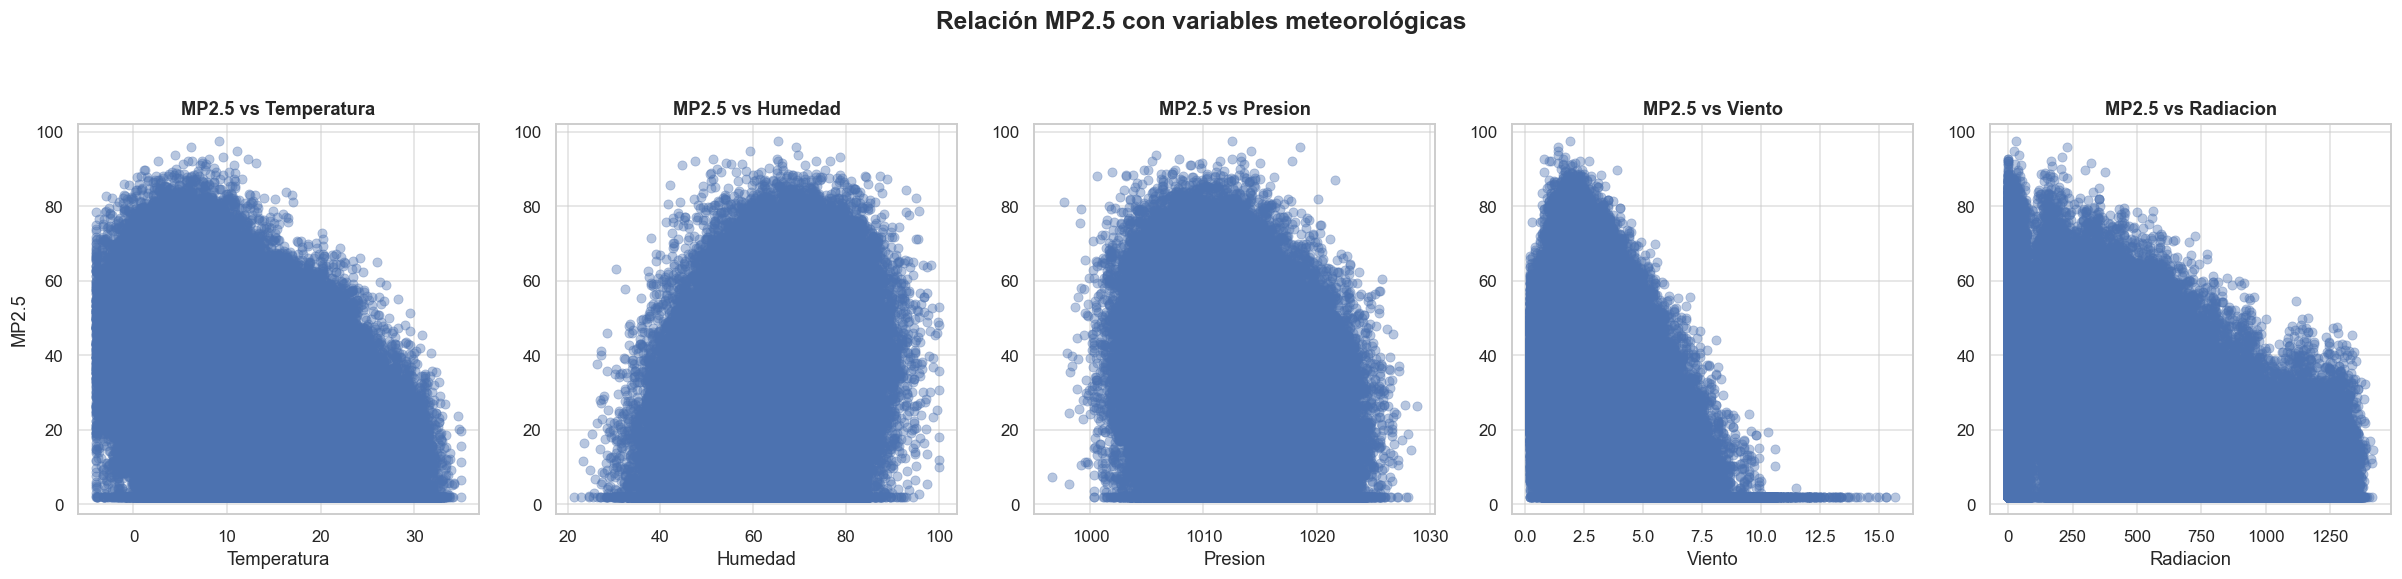

In [10]:
# ============================================================
# Relación MP2.5 versus variables meteorológicas
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración de estilo global
sns.set_theme(style="whitegrid")

# Trabajar sobre copia segura
df_plot = df_filtrado.copy()

# Normalizar fecha
df_plot["fecha"] = pd.to_datetime(
    df_plot["fecha"],
    errors="coerce"
)

df_plot = df_plot.dropna(subset=["fecha"]).copy()
df_plot["año_mes"] = df_plot["fecha"].dt.to_period("M").astype(str)

# Definir variable objetivo y variables meteorológicas
variable_objetivo = "mp2_5"

variables_num = [
    "temperatura",
    "humedad",
    "presion",
    "viento",
    "radiacion"
]

# Validar columnas disponibles
columnas_necesarias = [variable_objetivo] + variables_num
columnas_faltantes = [
    c for c in columnas_necesarias
    if c not in df_plot.columns
]

if columnas_faltantes:
    raise KeyError(
        f"Faltan columnas para graficar: {columnas_faltantes}. "
        f"Columnas disponibles: {df_plot.columns.tolist()}"
    )

# Asegurar formato numérico
for col in columnas_necesarias:
    df_plot[col] = pd.to_numeric(
        df_plot[col],
        errors="coerce"
    )

df_plot = df_plot.dropna(
    subset=columnas_necesarias
).reset_index(drop=True)

# Gráficos
fig, axes = plt.subplots(
    1,
    len(variables_num),
    figsize=(22, 5)
)

for i, var in enumerate(variables_num):
    sns.scatterplot(
        data=df_plot,
        x=var,
        y=variable_objetivo,
        ax=axes[i],
        alpha=0.4,
        edgecolor=None
    )

    titulo_var = var.replace("_", " ").capitalize()
    axes[i].set_title(f"MP2.5 vs {titulo_var}")
    axes[i].set_xlabel(titulo_var)

    if i == 0:
        axes[i].set_ylabel("MP2.5")
    else:
        axes[i].set_ylabel("")

plt.suptitle(
    "Relación MP2.5 con variables meteorológicas",
    fontsize=16,
    fontweight="bold",
    y=1.05
)

plt.tight_layout()
plt.show()



### 7.x Construcción del DataFrame con variables booleanas

El DataFrame `mp25_diario` (promedio diario) se agrega por día, comuna y estación, por lo que las variables cualitativas booleanas (`inversion_termica`, `es_finde`, `es_festivo`) no se conservan en esa agregación. Aquí se reconstruye `mp25_diario_con_boolean` reincorporando dichas variables —que son constantes dentro de cada día/comuna/estación— tomando su primer valor por grupo. Esto permite analizar la distribución de MP2.5 según cada condición booleana.

In [11]:
# ============================================================
# Reconstrucción del DataFrame diario con variables booleanas
# ============================================================

import pandas as pd

# Copia segura
df_bool = df_filtrado.copy()

# Crear solo_fecha desde fecha si no existe
if "solo_fecha" not in df_bool.columns:
    if "fecha" not in df_bool.columns:
        raise KeyError(
            f"No existe 'solo_fecha' ni 'fecha'. "
            f"Columnas disponibles: {df_bool.columns.tolist()}"
        )

    df_bool["fecha"] = pd.to_datetime(
        df_bool["fecha"],
        errors="coerce"
    )

    df_bool["solo_fecha"] = df_bool["fecha"].dt.date

# Variables booleanas esperadas
variables_bool = [
    "inversion_termica",
    "es_finde",
    "es_festivo"
]

# Booleanas presentes
bool_presentes = [
    c for c in variables_bool
    if c in df_bool.columns
]

faltantes_bool = [
    c for c in variables_bool
    if c not in df_bool.columns
]

if faltantes_bool:
    print(f"Aviso: columnas booleanas no encontradas: {faltantes_bool}")

# Validar columna objetivo
if "mp2_5" not in df_bool.columns:
    raise KeyError(
        f"No existe la columna 'mp2_5'. "
        f"Columnas disponibles: {df_bool.columns.tolist()}"
    )

# Validar columnas de agrupación
columnas_grupo = [
    "solo_fecha",
    "comuna",
    "estacion"
]

faltantes_grupo = [
    c for c in columnas_grupo
    if c not in df_bool.columns
]

if faltantes_grupo:
    raise KeyError(
        f"Faltan columnas de agrupación: {faltantes_grupo}. "
        f"Columnas disponibles: {df_bool.columns.tolist()}"
    )

# Asegurar MP2.5 numérico
df_bool["mp2_5"] = pd.to_numeric(
    df_bool["mp2_5"],
    errors="coerce"
)

# Normalizar booleanas Sí/No a 1/0 si existen
for col in bool_presentes:
    df_bool[col] = (
        df_bool[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({
            "sí": 1,
            "si": 1,
            "true": 1,
            "1": 1,
            "yes": 1,
            "no": 0,
            "false": 0,
            "0": 0
        })
    )

# Diccionario de agregación
agg_dict = {
    "mp2_5": "mean"
}

for c in bool_presentes:
    agg_dict[c] = "first"

# Construcción del DataFrame diario
mp25_diario_con_boolean = (
    df_bool
    .dropna(subset=["mp2_5", "solo_fecha", "comuna", "estacion"])
    .groupby(columnas_grupo, as_index=False)
    .agg(agg_dict)
    .rename(columns={
        "mp2_5": "mp2_5_promedio_diario"
    })
)

print(f"Filas en mp25_diario_con_boolean: {len(mp25_diario_con_boolean):,}")
print(f"Columnas: {list(mp25_diario_con_boolean.columns)}")

display(mp25_diario_con_boolean.head())

Filas en mp25_diario_con_boolean: 8,021
Columnas: ['solo_fecha', 'comuna', 'estacion', 'mp2_5_promedio_diario', 'inversion_termica', 'es_finde', 'es_festivo']


,solo_fecha,comuna,estacion,mp2_5_promedio_diario,inversion_termica,es_finde,es_festivo
0,2022-01-01,Cerrillos,Cerrillos,14.236364,1,1,1
1,2022-01-01,Cerro Navia,Cerro Navia,15.915789,1,1,1
2,2022-01-01,El Bosque,El Bosque,16.195652,1,1,1
3,2022-01-01,Independencia,Independencia,13.200000,1,1,1
4,2022-01-01,La Florida,La Florida,12.723810,0,1,1



Valores encontrados en 'inversion_termica':
inversion_termica
1    4130
0    3891
Name: count, dtype: int64

Valores encontrados en 'es_finde':
es_finde
0    5715
1    2306
Name: count, dtype: int64

Valores encontrados en 'es_festivo':
es_festivo
0    7648
1     373
Name: count, dtype: int64


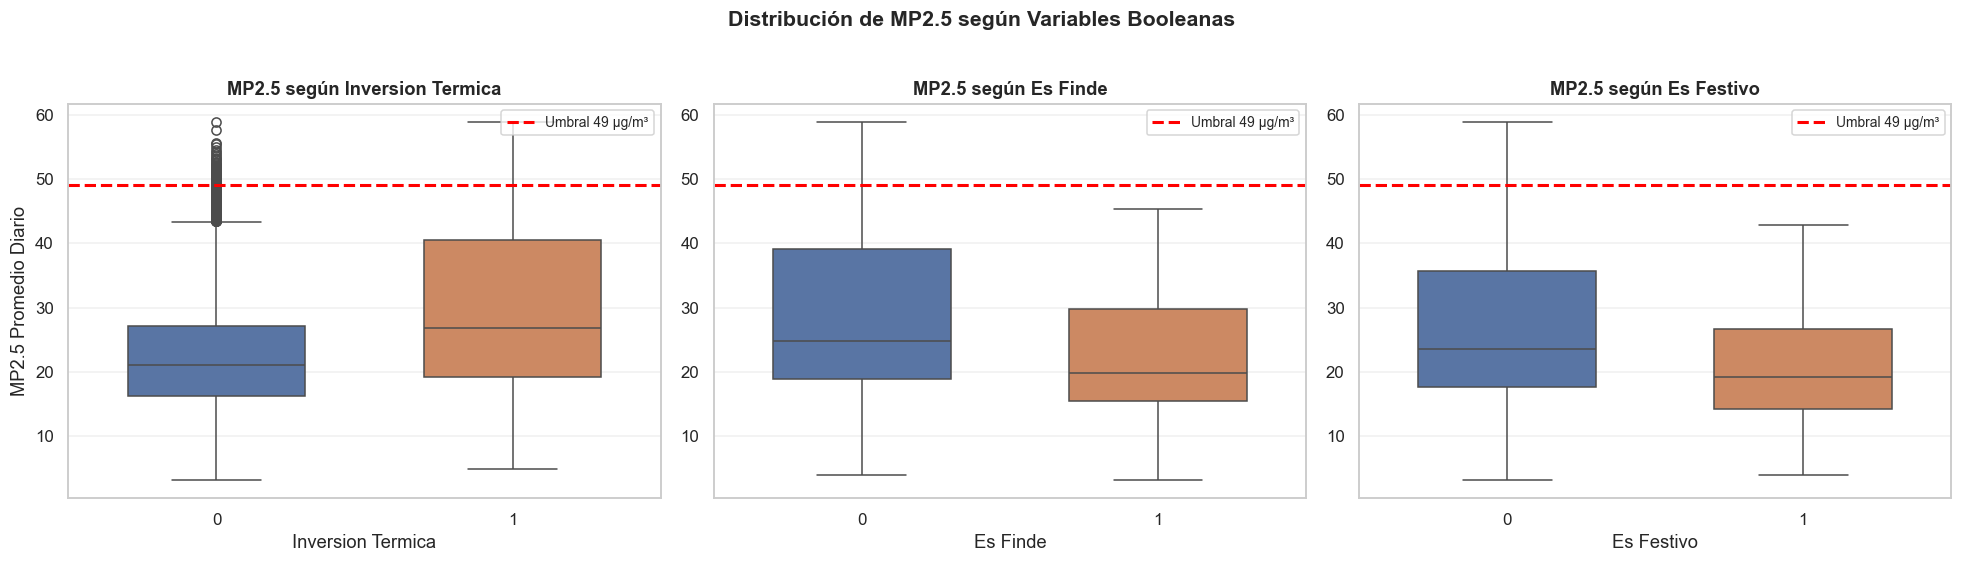

In [12]:
# ============================================================
# Boxplot de MP2.5 según variables booleanas
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Variables booleanas disponibles
cols_plot = [
    c for c in variables_bool
    if c in mp25_diario_con_boolean.columns
]

if len(cols_plot) == 0:
    raise ValueError(
        "No existen variables booleanas disponibles para graficar."
    )

# Validar columna objetivo
if "mp2_5_promedio_diario" not in mp25_diario_con_boolean.columns:
    raise KeyError(
        f"No existe 'mp2_5_promedio_diario'. "
        f"Columnas disponibles: {mp25_diario_con_boolean.columns.tolist()}"
    )

# Copia segura
df_box = mp25_diario_con_boolean.copy()

# Asegurar formato numérico de MP2.5
df_box["mp2_5_promedio_diario"] = pd.to_numeric(
    df_box["mp2_5_promedio_diario"],
    errors="coerce"
)

# Conversión robusta de booleanas
for var in cols_plot:

    print(f"\nValores encontrados en '{var}':")
    print(df_box[var].value_counts(dropna=False))

    df_box[var] = (
        df_box[var]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({
            "sí": 1,
            "si": 1,
            "true": 1,
            "1": 1,
            "yes": 1,

            "no": 0,
            "false": 0,
            "0": 0
        })
    )

    df_box[var] = pd.to_numeric(
        df_box[var],
        errors="coerce"
    )

# Eliminar registros inválidos
df_box = df_box.dropna(
    subset=["mp2_5_promedio_diario"]
).reset_index(drop=True)

# Umbral normativo
UMBRAL25 = 49

# Crear figura
n = len(cols_plot)

fig, axes = plt.subplots(
    1,
    n,
    figsize=(6 * n, 5)
)

if n == 1:
    axes = [axes]

# Generar boxplots
for idx, var in enumerate(cols_plot):

    sns.boxplot(
        data=df_box,
        x=var,
        y="mp2_5_promedio_diario",
        hue=var,
        legend=False,
        ax=axes[idx],
        width=0.6
    )

    titulo = var.replace("_", " ").title()

    axes[idx].set_title(
        f"MP2.5 según {titulo}",
        fontsize=12,
        fontweight="bold"
    )

    axes[idx].set_xlabel(titulo)

    if idx == 0:
        axes[idx].set_ylabel("MP2.5 Promedio Diario")
    else:
        axes[idx].set_ylabel("")

    axes[idx].axhline(
        UMBRAL25,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Umbral {UMBRAL25} µg/m³"
    )

    axes[idx].legend(
        loc="upper right",
        fontsize=9
    )

    axes[idx].grid(
        axis="y",
        alpha=0.3
    )

plt.suptitle(
    "Distribución de MP2.5 según Variables Booleanas",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

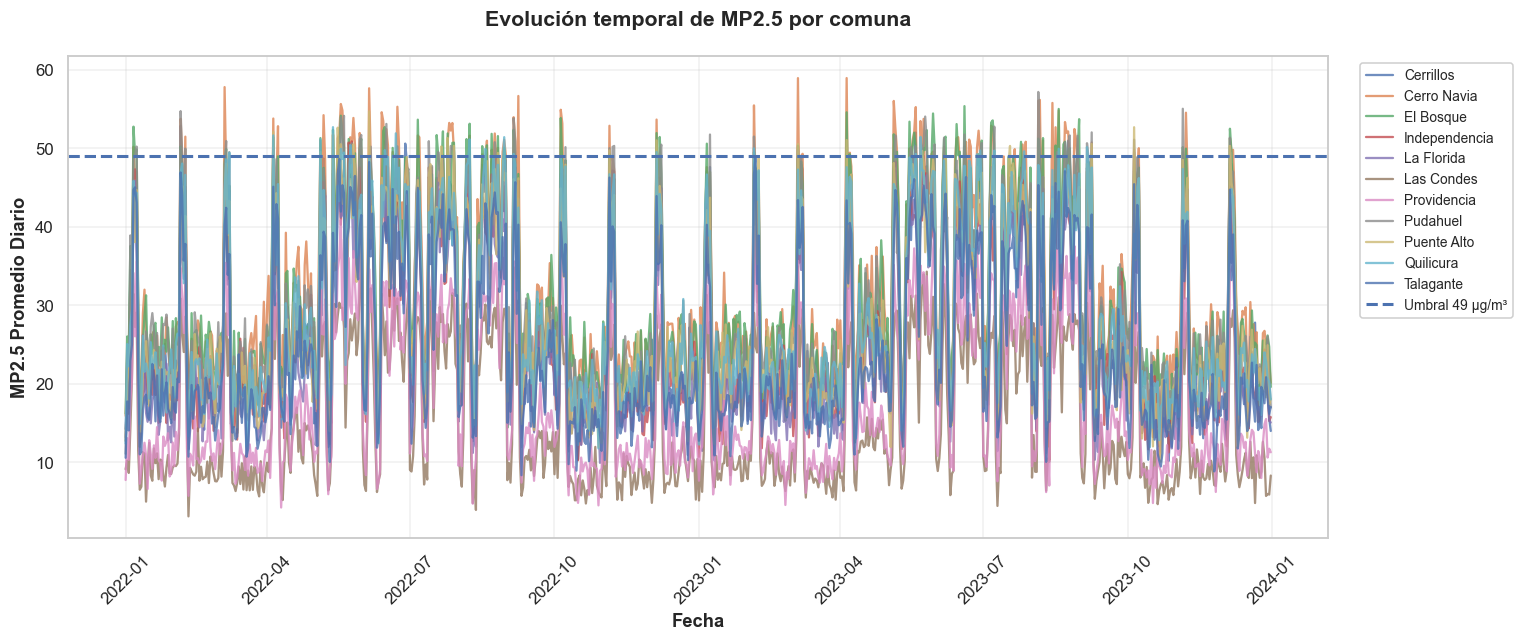

In [13]:
# ============================================================
# Gráfico de evolución temporal de MP2.5 por comuna
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

df_temporal = mp25_diario.copy()

# Validar columnas requeridas
columnas_requeridas = [
    "solo_fecha",
    "comuna",
    "mp2_5_promedio_diario"
]

faltantes = [
    c for c in columnas_requeridas
    if c not in df_temporal.columns
]

if faltantes:
    raise KeyError(
        f"Faltan columnas requeridas: {faltantes}. "
        f"Columnas disponibles: {df_temporal.columns.tolist()}"
    )

# Asegurar formatos
df_temporal["solo_fecha"] = pd.to_datetime(
    df_temporal["solo_fecha"],
    errors="coerce"
)

df_temporal["mp2_5_promedio_diario"] = pd.to_numeric(
    df_temporal["mp2_5_promedio_diario"],
    errors="coerce"
)

df_temporal = df_temporal.dropna(
    subset=["solo_fecha", "comuna", "mp2_5_promedio_diario"]
)

# Configuración
UMBRAL25 = 49

fig, ax = plt.subplots(figsize=(14, 6))

# Graficar una línea por comuna
for comuna in sorted(df_temporal["comuna"].dropna().unique()):
    datos_comuna = (
        df_temporal[df_temporal["comuna"] == comuna]
        .sort_values("solo_fecha")
    )

    ax.plot(
        datos_comuna["solo_fecha"],
        datos_comuna["mp2_5_promedio_diario"],
        label=comuna,
        linewidth=1.5,
        alpha=0.8
    )

# Línea de umbral
ax.axhline(
    UMBRAL25,
    linestyle="--",
    linewidth=2,
    label=f"Umbral {UMBRAL25} µg/m³"
)

ax.set_xlabel("Fecha", fontsize=12, fontweight="bold")
ax.set_ylabel("MP2.5 Promedio Diario", fontsize=12, fontweight="bold")
ax.set_title(
    "Evolución temporal de MP2.5 por comuna",
    fontsize=14,
    fontweight="bold",
    pad=20
)

ax.grid(True, alpha=0.3)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    fontsize=9,
    ncol=1,
    framealpha=0.95
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

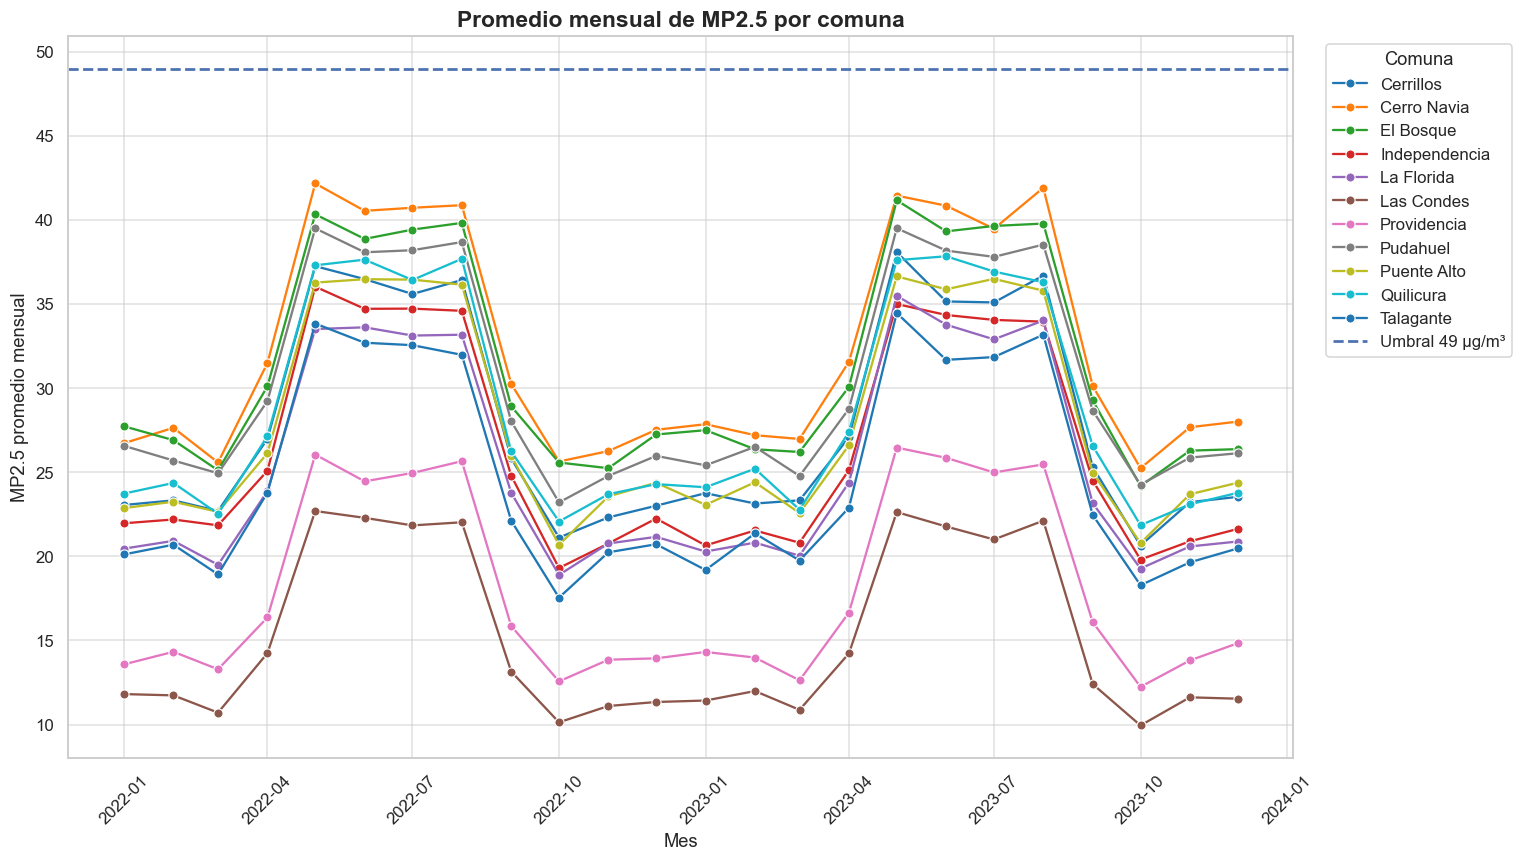

In [14]:
# ============================================================
# Promedio mensual de MP2.5 por comuna
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Copia segura
mp25_mensual_plot = df.copy()

# Validar columnas necesarias
columnas_requeridas = [
    "fecha",
    "comuna",
    "mp2_5"
]

faltantes = [
    c for c in columnas_requeridas
    if c not in mp25_mensual_plot.columns
]

if faltantes:
    raise KeyError(
        f"Faltan columnas requeridas: {faltantes}. "
        f"Columnas disponibles: {mp25_mensual_plot.columns.tolist()}"
    )

# Formatos correctos
mp25_mensual_plot["fecha"] = pd.to_datetime(
    mp25_mensual_plot["fecha"],
    errors="coerce"
)

mp25_mensual_plot["mp2_5"] = pd.to_numeric(
    mp25_mensual_plot["mp2_5"],
    errors="coerce"
)

mp25_mensual_plot = mp25_mensual_plot.dropna(
    subset=["fecha", "comuna", "mp2_5"]
)

# Crear mes
mp25_mensual_plot["mes"] = (
    mp25_mensual_plot["fecha"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# Agrupar promedio mensual
mp25_mensual_plot = (
    mp25_mensual_plot
    .groupby(["comuna", "mes"], as_index=False)
    .agg(mp2_5_promedio_mensual=("mp2_5", "mean"))
    .sort_values(["comuna", "mes"])
)

# Gráfico
UMBRAL25 = 49

fig, ax = plt.subplots(figsize=(14, 8))

sns.lineplot(
    data=mp25_mensual_plot,
    x="mes",
    y="mp2_5_promedio_mensual",
    hue="comuna",
    marker="o",
    linewidth=1.5,
    ax=ax,
    palette="tab10"
)

ax.axhline(
    UMBRAL25,
    linestyle="--",
    linewidth=1.8,
    label=f"Umbral {UMBRAL25} µg/m³"
)

ax.set_title(
    "Promedio mensual de MP2.5 por comuna",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Mes", fontsize=12)
ax.set_ylabel("MP2.5 promedio mensual", fontsize=12)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y-%m")
)

ax.tick_params(axis="x", rotation=45)

ax.legend(
    title="Comuna",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)

plt.tight_layout()
plt.show()



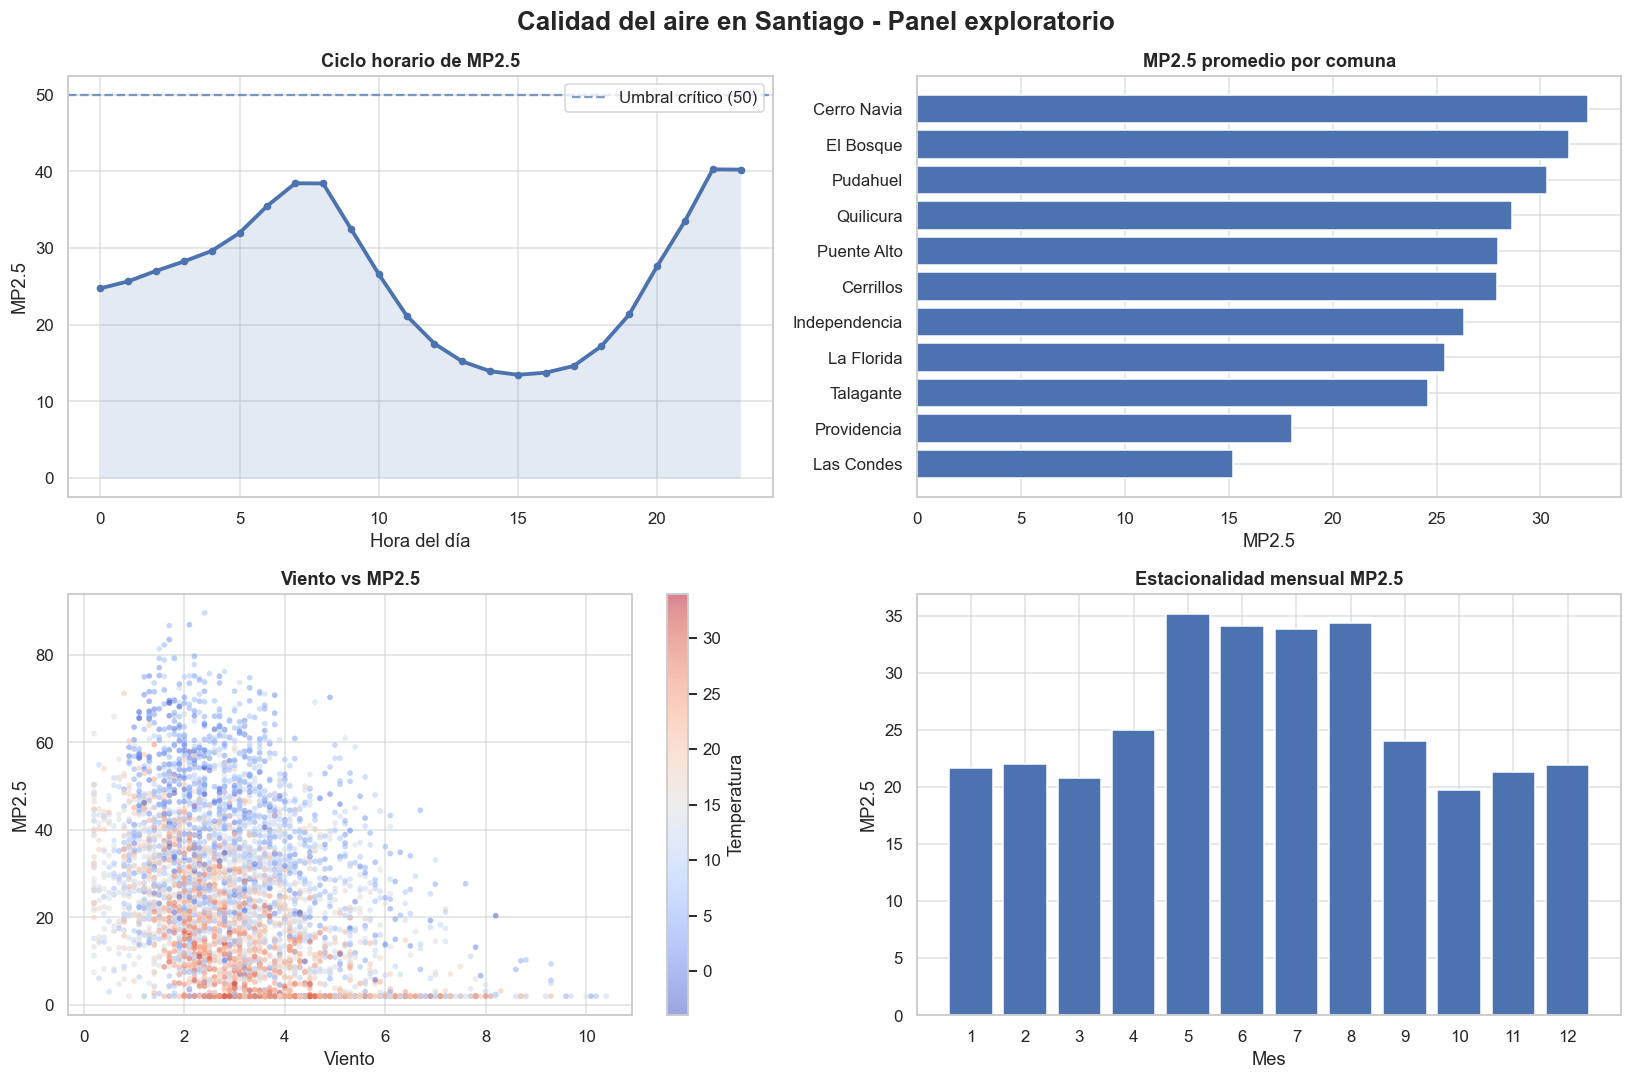

In [15]:
# ============================================================
# Calidad del aire en Santiago - Panel exploratorio
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

df_panel = df.copy()

# Validar columnas base
columnas_base = [
    "fecha",
    "comuna",
    "mp2_5",
    "viento",
    "temperatura"
]

faltantes = [c for c in columnas_base if c not in df_panel.columns]

if faltantes:
    raise KeyError(
        f"Faltan columnas base: {faltantes}. "
        f"Columnas disponibles: {df_panel.columns.tolist()}"
    )

# Crear hora y mes desde fecha
df_panel["fecha"] = pd.to_datetime(df_panel["fecha"], errors="coerce")
df_panel["hora"] = df_panel["fecha"].dt.hour
df_panel["mes"] = df_panel["fecha"].dt.month

# Asegurar numéricos
for col in ["mp2_5", "viento", "temperatura", "hora", "mes"]:
    df_panel[col] = pd.to_numeric(df_panel[col], errors="coerce")

df_panel = df_panel.dropna(
    subset=["fecha", "comuna", "mp2_5", "viento", "temperatura", "hora", "mes"]
).reset_index(drop=True)

UMBRAL = 50

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

fig.suptitle(
    "Calidad del aire en Santiago - Panel exploratorio",
    fontsize=17,
    fontweight="bold",
    y=0.98
)

# 1. Ciclo horario
ax = axes[0, 0]
ch = df_panel.groupby("hora")["mp2_5"].mean().sort_index()

ax.plot(ch.index, ch.values, linewidth=2.5, marker="o", markersize=4)
ax.fill_between(ch.index, ch.values, alpha=0.15)
ax.axhline(UMBRAL, linestyle="--", linewidth=1.5, alpha=0.7, label=f"Umbral crítico ({UMBRAL})")
ax.set_title("Ciclo horario de MP2.5")
ax.set_xlabel("Hora del día")
ax.set_ylabel("MP2.5")
ax.legend()

# 2. Ranking por comuna
ax = axes[0, 1]
rank = df_panel.groupby("comuna")["mp2_5"].mean().sort_values()

ax.barh(rank.index, rank.values)
ax.set_title("MP2.5 promedio por comuna")
ax.set_xlabel("MP2.5")

# 3. Viento vs MP2.5
ax = axes[1, 0]
s = df_panel.sample(min(4000, len(df_panel)), random_state=1)

sc = ax.scatter(
    s["viento"],
    s["mp2_5"],
    c=s["temperatura"],
    cmap="coolwarm",
    alpha=0.5,
    s=14,
    edgecolors="none"
)

ax.set_title("Viento vs MP2.5")
ax.set_xlabel("Viento")
ax.set_ylabel("MP2.5")

cb = plt.colorbar(sc, ax=ax)
cb.set_label("Temperatura")

# 4. Estacionalidad
ax = axes[1, 1]
mm = df_panel.groupby("mes")["mp2_5"].mean().sort_index()

ax.bar(mm.index, mm.values)
ax.set_title("Estacionalidad mensual MP2.5")
ax.set_xlabel("Mes")
ax.set_ylabel("MP2.5")
ax.set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

---
## 8. Correlaci&oacute;n entre variables

Mapa de calor que cuantifica la relaci&oacute;n lineal entre el MP2.5 y cada variable meteorol&oacute;gica.

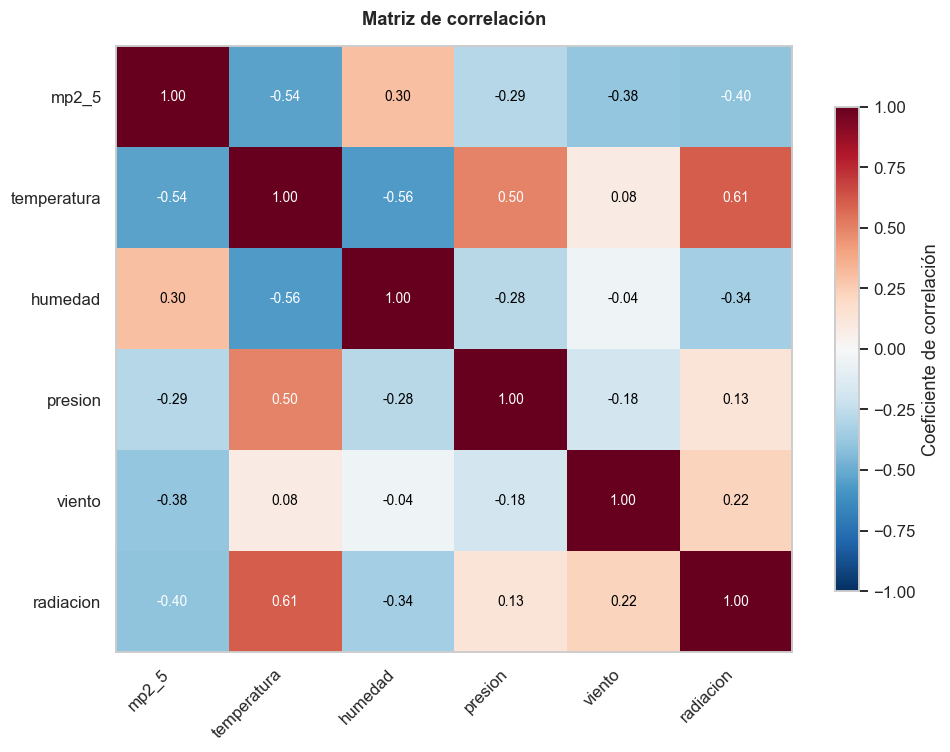

In [16]:
# ============================================================
# Correlación entre MP2.5 y variables meteorológicas
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Variables normalizadas
vars_corr = [
    "mp2_5",
    "temperatura",
    "humedad",
    "presion",
    "viento",
    "radiacion"
]

# Validar columnas existentes
vars_corr = [c for c in vars_corr if c in df.columns]

if "mp2_5" not in vars_corr:
    raise KeyError(
        f"No existe la columna 'mp2_5'. "
        f"Columnas disponibles: {df.columns.tolist()}"
    )

if len(vars_corr) < 2:
    raise ValueError(
        f"No hay suficientes variables para calcular correlación. "
        f"Variables disponibles: {vars_corr}"
    )

# Copia segura y conversión numérica
df_corr = df[vars_corr].copy()

for col in vars_corr:
    df_corr[col] = pd.to_numeric(
        df_corr[col],
        errors="coerce"
    )

df_corr = df_corr.dropna()

# Calcular correlación
corr = df_corr.corr()

# Graficar matriz de correlación
fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(
    corr.values,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    aspect="auto"
)

ax.set_xticks(range(len(vars_corr)))
ax.set_yticks(range(len(vars_corr)))

ax.set_xticklabels(
    vars_corr,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(vars_corr)

# Anotar valores
for i in range(len(vars_corr)):
    for j in range(len(vars_corr)):
        valor = corr.values[i, j]

        ax.text(
            j,
            i,
            f"{valor:.2f}",
            ha="center",
            va="center",
            color="white" if abs(valor) > 0.4 else "black",
            fontsize=9
        )

cb = fig.colorbar(im, ax=ax, shrink=0.8)
cb.set_label("Coeficiente de correlación")

ax.set_title(
    "Matriz de correlación",
    pad=14,
    fontweight="bold"
)

ax.grid(False)

plt.tight_layout()
plt.show()

Del mapa de calor se observa que las correlaciones entre M2.5 y el resto de magnitudes físicas son débiles. 

---
## 9. Condiciones que anticipan un episodio cr&iacute;tico

El análisis exploratorio realizado sobre el conjunto de datos de calidad del aire de la Región Metropolitana permitió identificar patrones relevantes asociados al comportamiento del material particulado fino (MP2.5). Sin embargo, los resultados obtenidos indican que las variables meteorológicas analizadas de manera individual presentan correlaciones lineales débiles o moderadas respecto de las concentraciones de MP2.5.

Este resultado sugiere que los episodios críticos de contaminación atmosférica no dependen de una única variable ambiental, sino de la interacción simultánea de múltiples factores, entre ellos condiciones meteorológicas, actividad urbana, emisiones vehiculares, procesos industriales, calefacción residencial y fenómenos atmosféricos locales.

A partir de las visualizaciones generadas se observan además patrones estacionales relevantes. Durante los meses de otoño e invierno se aprecia un aumento sostenido en los niveles promedio de MP2.5, comportamiento consistente con la evidencia reportada para la cuenca de Santiago, donde las condiciones de estabilidad atmosférica y ventilación reducida favorecen la acumulación de contaminantes.

Por otra parte, el análisis de variables categóricas asociadas a días festivos, fines de semana e inversión térmica evidencia diferencias en la distribución de las concentraciones de MP2.5, aunque los resultados observados no permiten establecer reglas determinísticas que anticipen por sí solas la ocurrencia de episodios críticos.

En consecuencia, los hallazgos obtenidos permiten concluir que la predicción de eventos de contaminación requiere modelos multivariados capaces de integrar simultáneamente variables meteorológicas, temporales y territoriales, constituyendo una línea de trabajo relevante para futuras etapas del proyecto.

---
## 10. Conclusiones preliminares

El presente análisis permitió desarrollar una exploración integral del conjunto de datos de calidad del aire de Santiago, aplicando procesos de limpieza, validación, transformación y visualización orientados a garantizar la calidad y consistencia de la información utilizada.

Los resultados obtenidos muestran que las concentraciones de MP2.5 presentan una dinámica compleja y multifactorial. Si bien las variables meteorológicas analizadas aportan información relevante para comprender el fenómeno, ninguna de ellas explica por sí sola las variaciones observadas en los niveles de contaminación atmosférica.

El análisis temporal evidenció patrones estacionales claros, observándose mayores concentraciones promedio de material particulado durante los meses de invierno. Este comportamiento resulta consistente con fenómenos ampliamente documentados en la Región Metropolitana, asociados a condiciones de menor ventilación atmosférica, inversión térmica y aumento de emisiones derivadas de actividades residenciales y urbanas.

Asimismo, el análisis por comuna permitió identificar diferencias territoriales significativas en los niveles promedio de contaminación, lo que sugiere la existencia de factores locales asociados a densidad poblacional, movilidad urbana, actividad económica y características geográficas específicas de cada zona.

Las matrices de correlación y visualizaciones exploratorias muestran que las relaciones entre MP2.5 y las variables meteorológicas son, en términos generales, débiles o moderadas, reforzando la hipótesis de que la contaminación atmosférica responde a la interacción simultánea de múltiples factores ambientales y antropogénicos.

Desde una perspectiva metodológica, el trabajo desarrollado permitió construir una base de datos limpia, estructurada y reproducible, apta para etapas posteriores de análisis avanzado, modelamiento predictivo y aplicaciones de Machine Learning.

Como trabajo futuro, se recomienda incorporar técnicas de modelado supervisado, análisis multivariado y series temporales con el objetivo de identificar patrones complejos, estimar concentraciones futuras de contaminantes y apoyar procesos de monitoreo y toma de decisiones relacionados con la gestión de la calidad del aire en la Región Metropolitana de Santiago.

Esta versión está mucho más alineada con lo que espera un profesor de Magíster: se basa en evidencia observada, evita afirmaciones absolutas, conecta con los análisis que realizaste (correlación, temporalidad, comunas, variables meteorológicas) y deja una transición natural hacia futuras fases de Machine Learning. Además, es consistente con el nivel técnico que ya has incorporado en F3.